In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from src.sae_ts.inteval.utils import bf_kl_behavour, new_bf_kl_behavour
import os
import sys
import pandas as pd

In [2]:
base_path = '/Users/z5517269/Desktop/Repos/intsteer/steer_cfgs'
output_path = 'regression.csv'
scores = pd.read_csv('evals.csv')

judges = ['models/gemini-2.5-flash'] # "models/gemini-2.5-flash" 'gpt-4o-mini'
models = ['gemma2', 'gemma2-9b'] # , 'gemma2-9b'
criteria = [
    ('anger', 'anger'),
    ('christian_evangelist', 'Christian'),
    ('conspiracy', 'conspiracy'),
    ('french', 'French'),
    ('london', 'London'),
    ('love', 'love'),
    ('praise', 'praise'),
    ('want_to_die', 'want to die'),
    ('wedding', 'wedding')
]
extraction_methods = ['SAE', 'ActSteer']
steering_methods = ['addition', 'rotation']


# ---------------------------------------------------
# Main evaluation loop
# ---------------------------------------------------
rows_to_append = {
                'scale': [],
                
                # KL before
                'kl_before_mean': [],
                'kl_before_std': [],
                'kl_before_var': [],
                'kl_before_min': [],
                'kl_before_max': [],
                'kl_before_median': [],
                'kl_before_iqr': [],
                'kl_before_range': [],
                'kl_before_skew': [],
                'kl_before_kurt': [],

                # KL after
                'kl_after_mean': [],
                'kl_after_std': [],
                'kl_after_var': [],
                'kl_after_min': [],
                'kl_after_max': [],
                'kl_after_median': [],
                'kl_after_iqr': [],
                'kl_after_range': [],
                'kl_after_skew': [],
                'kl_after_kurt': [],

                # bf / entropy_last
                'bf_mean': [],
                'bf_std': [],
                'bf_var': [],
                'bf_min': [],
                'bf_max': [],
                'bf_median': [],
                'bf_iqr': [],
                'bf_range': [],
                'bf_skew': [],
                'bf_kurt': [],

                # ibf
                'ibf_mean': [],
                'ibf_std': [],
                'ibf_var': [],
                'ibf_min': [],
                'ibf_max': [],
                'ibf_median': [],
                'ibf_iqr': [],
                'ibf_range': [],
                'ibf_skew': [],
                'ibf_kurt': [],
                'pattern': [], 

                'experiment_index':[], 
                'coherence':[], 
                'behaviour':[], 
                'product':[], 
                'solution':[], 
                'concept':[], 

                }
counter = 0
for judge in judges:
    for model in models:
        for c1, c2 in criteria:
            for extraction_method in extraction_methods:
                for steering_method in steering_methods:
                    file_path = f'{base_path}/{model}/{c1}/{steering_method}_{c2}_{extraction_method}.json'
                    
                    data = new_bf_kl_behavour(
                        file_path,
                        )
                    # print(data['pattern'])
                    # sys.exit()
                    temp = scores[(scores.path==f'{base_path}/{model}/{c1}')&
                                    (scores.extraction_method==extraction_method)&
                                    (scores.steering_method==steering_method)&
                                    (scores.judge==judge)]
                    # print(data)
                    try:
                        data['experiment_index'] = 16*[counter]
                        data['coherence'] = eval(temp.avg_coherence.iloc[0])
                        data['behaviour'] = eval(temp.avg_score.iloc[0])
                        data['product'] = eval(temp['product'].iloc[0])
                        data['solution'] = 16*[extraction_method]
                        data['concept'] = 16*[c2]
                        for k, v in data.items():
                            rows_to_append[k]+=v
                            # print(k, '=>', v)
                        # sys.exit()
                    except:
                        print(data)
                        print(file_path)
                    print(counter, '=>', file_path)
                    counter+=1

# for k,v in rows_to_append.items():
#     print(k, '=', len(v))
df = pd.DataFrame(rows_to_append)
df

0 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/anger/addition_anger_SAE.json
1 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/anger/rotation_anger_SAE.json
2 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/anger/addition_anger_ActSteer.json
3 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/anger/rotation_anger_ActSteer.json
4 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/christian_evangelist/addition_Christian_SAE.json
5 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/christian_evangelist/rotation_Christian_SAE.json
6 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/christian_evangelist/addition_Christian_ActSteer.json
7 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/christian_evangelist/rotation_Christian_ActSteer.json
8 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/conspiracy/addition_conspiracy_SAE.json
9 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/cons

/Users/z5517269/Desktop/SAE-TS/src/sae_ts/inteval/utils.py:36: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'skew':   float(skew(x)),
/Users/z5517269/Desktop/SAE-TS/src/sae_ts/inteval/utils.py:37: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'kurt':   float(kurtosis(x)),


19 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/london/rotation_London_ActSteer.json
20 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/love/addition_love_SAE.json
21 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/love/rotation_love_SAE.json
22 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/love/addition_love_ActSteer.json
23 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/love/rotation_love_ActSteer.json
24 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/praise/addition_praise_SAE.json
25 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/praise/rotation_praise_SAE.json
26 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/praise/addition_praise_ActSteer.json
27 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/praise/rotation_praise_ActSteer.json
28 => /Users/z5517269/Desktop/Repos/intsteer/steer_cfgs/gemma2/want_to_die/addition_want to die_SAE.json
29 => /Users/z5517269/Desktop/R

,scale,kl_before_mean,kl_before_std,kl_before_var,kl_before_min,kl_before_max,kl_before_median,kl_before_iqr,kl_before_range,kl_before_skew,...,ibf_range,ibf_skew,ibf_kurt,pattern,experiment_index,coherence,behaviour,product,solution,concept
0,0,11.997515,0.606947,0.368385,9.895072,12.546165,12.324944,0.720675,2.651093,-1.575424,...,0.967515,-0.903657,1.217763,0.951095,0,0.830729,0.063368,0.052642,SAE,anger
1,1,12.052356,0.478922,0.229366,10.538668,12.544954,12.262132,0.599997,2.006287,-1.405573,...,1.322386,-0.154468,1.346049,0.906552,0,0.779514,0.081163,0.063268,SAE,anger
2,2,12.174491,0.342412,0.117246,11.423656,12.545855,12.335422,0.568524,1.122198,-0.775863,...,1.243947,-0.360904,2.266526,0.936633,0,0.778646,0.255208,0.198717,SAE,anger
3,3,11.989850,0.513531,0.263714,10.388334,12.540362,12.154298,0.819640,2.152028,-1.018545,...,0.946660,0.273254,2.806226,0.937723,0,0.716580,0.405816,0.290800,SAE,anger
4,4,12.054540,0.631338,0.398588,9.498496,12.546228,12.285679,0.482354,3.047732,-2.544735,...,1.551754,4.497541,20.298444,0.859163,0,0.600260,0.427951,0.256882,SAE,anger
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,11,11.866781,0.502288,0.252293,10.020627,12.399805,12.008243,0.385856,2.379178,-2.010675,...,0.560364,-3.243973,12.115741,0.749922,71,0.029514,0.212674,0.006277,ActSteer,wedding
1148,12,11.524923,0.948718,0.900067,8.675039,12.381784,11.855999,1.053185,3.706745,-1.503571,...,0.256132,-1.949671,6.092454,0.420619,71,0.000000,0.009115,0.000000,ActSteer,wedding
1149,13,11.224878,0.728077,0.530097,9.886810,12.381784,11.384784,1.223822,2.494974,-0.229481,...,0.096600,-0.228816,1.388952,0.275489,71,0.000000,0.010851,0.000000,ActSteer,wedding
1150,14,11.616248,0.648234,0.420208,10.157894,12.381784,11.780786,0.975650,2.223890,-0.728273,...,0.038683,0.016239,-0.578004,0.142212,71,0.000000,0.043403,0.000000,ActSteer,wedding


In [3]:
import pandas as pd
import sys
# df = pd.read_csv("data.csv")
diff_bf = []
diff_ibf = []
diff_kl_after = []
diff_kl_before = []
for idx, row in df.iterrows():
    # print(row)
    if row['scale']==0:
        diff_bf.append(0.0)
        diff_ibf.append(0.0)
        diff_kl_after.append(0.0)
        diff_kl_before.append(0.0)
    else:
        solution = row['solution']
        concept = row['concept']
        temp_bf = df[(df.solution==solution)&(df.concept==concept)].iloc[0, 21]
        temp_ibf = df[(df.solution==solution)&(df.concept==concept)].iloc[0, 31]
        temp_kl_after = df[(df.solution==solution)&(df.concept==concept)].iloc[0, 11]
        temp_kl_before = df[(df.solution==solution)&(df.concept==concept)].iloc[0, 1]
        diff_bf.append(float(row['bf_mean']/temp_bf))
        diff_ibf.append(float(row['ibf_mean']/temp_ibf))
        diff_kl_after.append(float(row['kl_after_mean']/temp_kl_after))
        diff_kl_before.append(float(row['kl_before_mean']/temp_kl_before))
df['diff_bf'] = diff_bf
df['diff_ibf'] = diff_ibf
df['diff_kl_after'] = diff_kl_after
df['diff_kl_before'] = diff_kl_before
df

,scale,kl_before_mean,kl_before_std,kl_before_var,kl_before_min,kl_before_max,kl_before_median,kl_before_iqr,kl_before_range,kl_before_skew,...,experiment_index,coherence,behaviour,product,solution,concept,diff_bf,diff_ibf,diff_kl_after,diff_kl_before
0,0,11.997515,0.606947,0.368385,9.895072,12.546165,12.324944,0.720675,2.651093,-1.575424,...,0,0.830729,0.063368,0.052642,SAE,anger,0.000000,0.000000,0.000000,0.000000
1,1,12.052356,0.478922,0.229366,10.538668,12.544954,12.262132,0.599997,2.006287,-1.405573,...,0,0.779514,0.081163,0.063268,SAE,anger,0.352674,1.019276,1.001009,1.004571
2,2,12.174491,0.342412,0.117246,11.423656,12.545855,12.335422,0.568524,1.122198,-0.775863,...,0,0.778646,0.255208,0.198717,SAE,anger,0.338349,1.023489,1.005083,1.014751
3,3,11.989850,0.513531,0.263714,10.388334,12.540362,12.154298,0.819640,2.152028,-1.018545,...,0,0.716580,0.405816,0.290800,SAE,anger,0.360093,0.998629,0.994919,0.999361
4,4,12.054540,0.631338,0.398588,9.498496,12.546228,12.285679,0.482354,3.047732,-2.544735,...,0,0.600260,0.427951,0.256882,SAE,anger,0.364629,0.850343,0.983711,1.004753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,11,11.866781,0.502288,0.252293,10.020627,12.399805,12.008243,0.385856,2.379178,-2.010675,...,71,0.029514,0.212674,0.006277,ActSteer,wedding,5.974753,0.841016,1.009318,1.004186
1148,12,11.524923,0.948718,0.900067,8.675039,12.381784,11.855999,1.053185,3.706745,-1.503571,...,71,0.000000,0.009115,0.000000,ActSteer,wedding,8.138854,0.680817,1.018529,0.975258
1149,13,11.224878,0.728077,0.530097,9.886810,12.381784,11.384784,1.223822,2.494974,-0.229481,...,71,0.000000,0.010851,0.000000,ActSteer,wedding,21.852301,0.601793,1.017799,0.949867
1150,14,11.616248,0.648234,0.420208,10.157894,12.381784,11.780786,0.975650,2.223890,-0.728273,...,71,0.000000,0.043403,0.000000,ActSteer,wedding,22.153570,0.583539,1.018921,0.982986


In [4]:
# import pandas as pd
# import numpy as np 
# # -----------------------------
# # 1. Required numeric columns
# # -----------------------------
# numeric_cols = [
#     "product",
#     "bf_mean",
#     "kl_before_mean",
#     "kl_after_mean",
# ]

# # -----------------------------
# # 2. Force float() conversion
# # -----------------------------
# for col in numeric_cols:
#     df[col] = df[col].apply(lambda x: float(x))

# # -----------------------------
# # 3. Add unique row id
# # -----------------------------
# df = df.reset_index(drop=True)
# df["id"] = df.index

# # -----------------------------
# # 4. Cartesian self-join
# # -----------------------------
# pairs = df.merge(df, how="cross", suffixes=("_1", "_2"))

# # -----------------------------
# # 5. Apply conditions
# # -----------------------------
# filtered_pairs = pairs[
#     ((pairs["product_1"] - pairs["product_2"])>0.1) &
#     (pairs["bf_mean_1"] < pairs["bf_mean_2"]) &
#     ((pairs["bf_mean_2"]-pairs["bf_mean_1"])<2)&
#     (0.1 < pairs["product_2"]) &
#     (
#         (pairs["kl_before_mean_1"] - pairs["kl_after_mean_1"]) >
#         (pairs["kl_before_mean_2"] - pairs["kl_after_mean_2"])
#     ) &
#     (
#         (np.abs(pairs["kl_before_mean_1"] - pairs["kl_after_mean_1"]) - np.abs(pairs["kl_before_mean_2"] - pairs["kl_after_mean_2"]))>0.3
#     ) &
#     ((pairs["kl_before_mean_2"] - pairs["kl_after_mean_2"])<0) &
#     (pairs["id_1"] != pairs["id_2"])&
#     (np.abs(pairs["id_1"]-pairs["id_2"])<16)
# ]

# # -----------------------------
# # 6. Final result
# # -----------------------------
# result = filtered_pairs[
#     [
#         "id_1", "id_2",
#         "product_1", "product_2",
#         "bf_mean_1", "bf_mean_2",
#         "kl_before_mean_1", "kl_after_mean_1",
#         "kl_before_mean_2", "kl_after_mean_2", "experiment_index_1", "experiment_index_2",
#     ]
# ]

# print(result)


In [5]:

correlation = df['coherence'].corr(df['pattern'])
print("Correlation:", correlation)


Correlation: 0.7198391912727675


In [6]:
print(list(df.columns))

['scale', 'kl_before_mean', 'kl_before_std', 'kl_before_var', 'kl_before_min', 'kl_before_max', 'kl_before_median', 'kl_before_iqr', 'kl_before_range', 'kl_before_skew', 'kl_before_kurt', 'kl_after_mean', 'kl_after_std', 'kl_after_var', 'kl_after_min', 'kl_after_max', 'kl_after_median', 'kl_after_iqr', 'kl_after_range', 'kl_after_skew', 'kl_after_kurt', 'bf_mean', 'bf_std', 'bf_var', 'bf_min', 'bf_max', 'bf_median', 'bf_iqr', 'bf_range', 'bf_skew', 'bf_kurt', 'ibf_mean', 'ibf_std', 'ibf_var', 'ibf_min', 'ibf_max', 'ibf_median', 'ibf_iqr', 'ibf_range', 'ibf_skew', 'ibf_kurt', 'pattern', 'experiment_index', 'coherence', 'behaviour', 'product', 'solution', 'concept', 'diff_bf', 'diff_ibf', 'diff_kl_after', 'diff_kl_before']


In [7]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor


# ================================
# 1. Features / Targets / Groups
# ================================
X = df[['scale', 'kl_before_mean', 'kl_before_std', 'kl_before_var', 'kl_before_min', 'kl_before_max', 
        'kl_before_median', 'kl_before_iqr', 'kl_before_range', 'kl_before_skew', 'kl_before_kurt',
        'kl_after_mean', 'kl_after_std', 'kl_after_var', 'kl_after_min', 'kl_after_max', 
        'kl_after_median', 'kl_after_iqr', 'kl_after_range', 'kl_after_skew', 'kl_after_kurt',
        'bf_mean', 'bf_std', 'bf_var', 'bf_min', 'bf_max', 'bf_median', 'bf_iqr', 
        'bf_range', 'bf_skew', 'bf_kurt',
        'ibf_mean', 'ibf_std', 'ibf_var', 'ibf_min', 'ibf_max', 'ibf_median', 
        'ibf_iqr', 'ibf_range', 'ibf_skew', 'ibf_kurt',
        'pattern', 'diff_bf', 'diff_ibf', 'diff_kl_after', 'diff_kl_before']]

Y = df[["coherence", "behaviour", "product"]]
target_names = Y.columns.tolist()

groups = df["experiment_index"]


# ================================
# 2. Scaling
# ================================
scaler = ColumnTransformer(
    [("num", StandardScaler(), X.columns)],
    remainder="passthrough"
)


# ================================
# 3. Model
# ================================

# from lightgbm import LGBMRegressor

# def build_model(seed):
#     return LGBMRegressor(
#         n_estimators=700,
#         learning_rate=0.03,
#         max_depth=-1,
#         num_leaves=64,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         objective="regression_l1",  # MAE
#         random_state=seed,
#         n_jobs=-1, 
#         verbosity=-1
#     )
from sklearn.ensemble import RandomForestRegressor
def build_model(seed):
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=None,            # let trees grow fully unless data dictates otherwise
        max_features="sqrt",       # strong default for tabular data
        min_samples_split=2,
        min_samples_leaf=1,
        bootstrap=True,
        random_state=seed,
        n_jobs=-1
    )


# ================================
# 4. Seeds & metric storage
# ================================
seeds = [22, 42, 31, 61, 10]

overall_metrics = {
    "MAE": [],
    "RMSE": [],
    "R2": []
}

per_target_metrics = {
    t: {"MAE": [], "RMSE": [], "R2": []}
    for t in target_names
}


# ================================
# 5. Training loop
# ================================
for seed in seeds:
    print(f"\n======================")
    print(f" Seed = {seed}")
    print("======================")

    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.30,
        random_state=seed
    )

    train_idx, test_idx = next(gss.split(X, Y, groups=groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    # print(X_train.shape, Y_test.shape, X_test.shape, Y_train.shape)
    preds = np.zeros_like(Y_test.values, dtype=float)

    for i, t in enumerate(target_names):
        model = Pipeline([
            ("scale", scaler),
            ("reg", build_model(seed))
        ])
        model.fit(X_train, Y_train[t])
        preds[:, i] = model.predict(X_test)
    # preds[:, -1] = preds[:, 0]*preds[:, 1]
    # ================================
    # Metrics (overall)
    # ================================
    overall_metrics["MAE"].append(
        mean_absolute_error(Y_test, preds)
    )
    overall_metrics["RMSE"].append(
        np.sqrt(mean_squared_error(Y_test, preds))
    )
    overall_metrics["R2"].append(
        r2_score(Y_test, preds)
    )

    # ================================
    # Metrics (per target)
    # ================================
    for i, t in enumerate(target_names):
        per_target_metrics[t]["MAE"].append(
            mean_absolute_error(Y_test.iloc[:, i], preds[:, i])
        )
        per_target_metrics[t]["RMSE"].append(
            np.sqrt(mean_squared_error(Y_test.iloc[:, i], preds[:, i]))
        )
        per_target_metrics[t]["R2"].append(
            r2_score(Y_test.iloc[:, i], preds[:, i])
        )

    # ================================
    # Sanity check
    # ================================
    shared_experiments = (
        set(df.iloc[train_idx]["experiment_index"])
        & set(df.iloc[test_idx]["experiment_index"])
    )
    assert len(shared_experiments) == 0, "❌ experiment_index leakage detected!"


# ================================
# 6. Final Report (mean & var)
# ================================
print("\n==============================")
print(" Final Results (mean ± var)")
print("==============================")

print("\n--- Overall Performance ---")
for m in ["MAE", "RMSE", "R2"]:
    mean = np.mean(overall_metrics[m])
    var = np.var(overall_metrics[m])
    print(f"{m}: {mean:.4f} ± {var:.4f}")

print("\n--- Per-Target Results ---")
for t in target_names:
    print(f"\n{t}")
    for m in ["MAE", "RMSE", "R2"]:
        mean = np.mean(per_target_metrics[t][m])
        var = np.var(per_target_metrics[t][m])
        print(f"{m}: {mean:.4f} ± {var:.4f}")

print("\n✔ No experiment_index leakage across all splits")



 Seed = 22

 Seed = 42

 Seed = 31

 Seed = 61

 Seed = 10

 Final Results (mean ± var)

--- Overall Performance ---
MAE: 0.1289 ± 0.0001
RMSE: 0.1789 ± 0.0002
R2: 0.5898 ± 0.0015

--- Per-Target Results ---

coherence
MAE: 0.0822 ± 0.0001
RMSE: 0.1102 ± 0.0001
R2: 0.8745 ± 0.0004

behaviour
MAE: 0.2174 ± 0.0003
RMSE: 0.2653 ± 0.0005
R2: 0.3503 ± 0.0050

product
MAE: 0.0871 ± 0.0000
RMSE: 0.1160 ± 0.0001
R2: 0.5445 ± 0.0012

✔ No experiment_index leakage across all splits


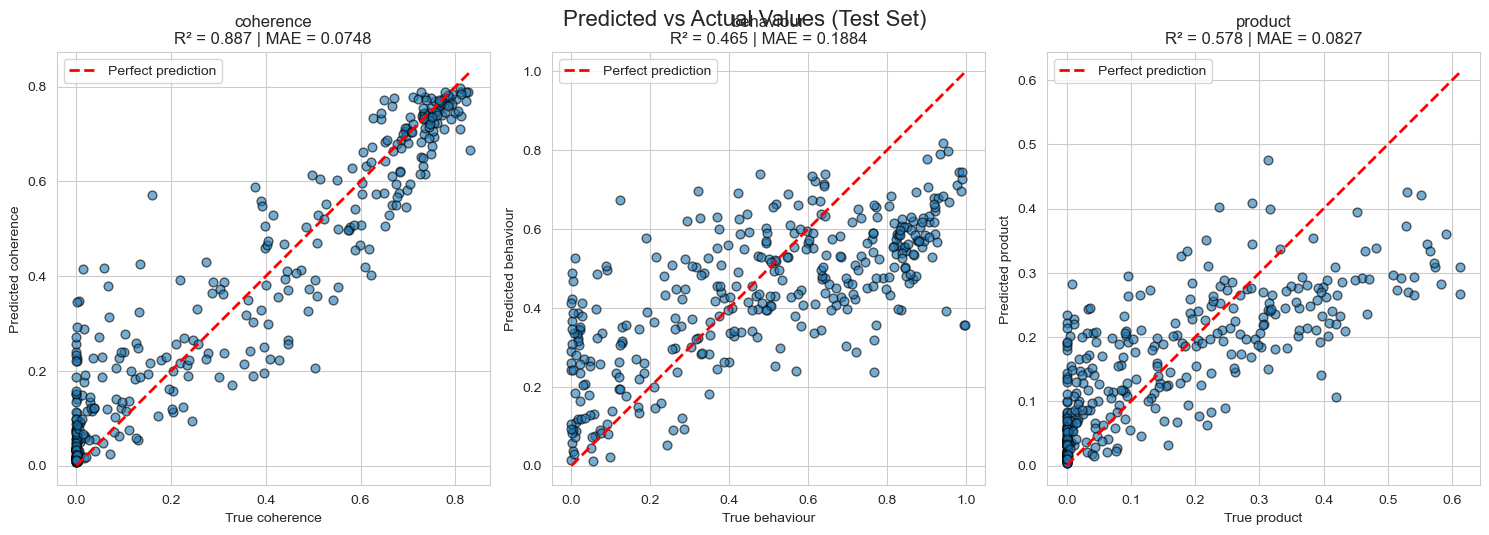

In [8]:
# ================================
# 8. Plot Predicted vs Actual
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, t in enumerate(target_names):
    ax = axes[i]
    
    y_true = Y_test.iloc[:, i].values
    y_pred = preds[:, i]
    
    # Compute metrics for title
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Decide plot type based on number of points
    if len(y_true) > 1000:
        # Use hexbin for dense data to avoid overplotting
        hb = ax.hexbin(y_true, y_pred, gridsize=50, cmap='Blues', mincnt=1)
        plt.colorbar(hb, ax=ax, label='count')
    else:
        # Scatter with alpha for transparency
        ax.scatter(y_true, y_pred, alpha=0.6, edgecolor='k', s=40)
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Perfect prediction")
    
    ax.set_xlabel(f"True {t}")
    ax.set_ylabel(f"Predicted {t}")
    ax.set_title(f"{t}\nR² = {r2:.3f} | MAE = {mae:.4f}")
    ax.legend()
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.suptitle("Predicted vs Actual Values (Test Set)", fontsize=16, y=1.02)
plt.show()

In [9]:
for i, j in zip(y_true, y_pred):
    print(f'({i}, {j})')

(0.04726833767361111, 0.046210298024785275)
(0.13611009385850695, 0.1135318083283485)
(0.20431518554687503, 0.1960931553190265)
(0.3127856807210902, 0.24284203474373317)
(0.4128613884066358, 0.24033831811832737)
(0.409041536730887, 0.22178012668232394)
(0.3739053231698496, 0.2139825788842537)
(0.3604323628400343, 0.2018128815987172)
(0.30644905424446867, 0.2317432840097302)
(0.23885957694347995, 0.2523779792103646)
(0.18600037200074399, 0.1377464071375607)
(0.15132034941244318, 0.06964036267597927)
(0.09881422924901184, 0.05522545433130079)
(0.07779006298753337, 0.027972231421776933)
(0.06277927292921526, 0.021889781302492643)
(0.03219720019686952, 0.021042256220282617)
(0.040295259452160496, 0.018115142672590005)
(0.14024522569444445, 0.16011308327730622)
(0.24113802383698577, 0.21176150120841497)
(0.4039357503255208, 0.26230132419608737)
(0.4291289674911358, 0.28568781164529444)
(0.42160384958738856, 0.2648333187465418)
(0.30050153055251294, 0.20696594690216805)
(0.20192703192443937,